In [12]:
!pip install torch torchvision numpy matplotlib scikit-learn pillow -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Devan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [14]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.softmax(preds, dim=1)
        num_classes = preds.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        intersection = (preds * targets_one_hot).sum(dim=(2, 3))
        union = preds.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.ce    = nn.CrossEntropyLoss()
        self.dice  = DiceLoss(smooth)

    def forward(self, preds, targets):
        return self.alpha * self.ce(preds, targets) + (1 - self.alpha) * self.dice(preds, targets)


B, K, H, W = 2, 3, 64, 64
logits  = torch.randn(B, K, H, W)
targets = torch.randint(0, K, (B, H, W))

ce_loss   = nn.CrossEntropyLoss()(logits, targets)
dice_loss = DiceLoss()(logits, targets)
comb_loss = CombinedLoss()(logits, targets)

print('Cross-Entropy Loss :', round(ce_loss.item(), 4))
print('Dice Loss          :', round(dice_loss.item(), 4))
print('Combined Loss      :', round(comb_loss.item(), 4))

Cross-Entropy Loss : 1.3881
Dice Loss          : 0.6664
Combined Loss      : 1.0272


In [15]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class SimpleFCN(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBNReLU(in_channels, 32),
            nn.MaxPool2d(2),
            ConvBNReLU(32, 64),
            nn.MaxPool2d(2),
            ConvBNReLU(64, 128),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return self.classifier(x)


fcn   = SimpleFCN(in_channels=3, num_classes=3).to(DEVICE)
x     = torch.randn(1, 3, 64, 64).to(DEVICE)
out   = fcn(x)

print('FCN Input  :', tuple(x.shape))
print('FCN Output :', tuple(out.shape))
print('FCN Params :', f"{sum(p.numel() for p in fcn.parameters()):,}")

FCN Input  : (1, 3, 64, 64)
FCN Output : (1, 3, 64, 64)
FCN Params : 257,507


In [16]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs, self.ups = nn.ModuleList(), nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.ups.append(DoubleConv(f * 2, f))

        self.head = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i + 1](x)

        return self.head(x)


unet = UNet(in_channels=3, num_classes=3).to(DEVICE)
x    = torch.randn(1, 3, 128, 128).to(DEVICE)
out  = unet(x)

print('U-Net Input  :', tuple(x.shape))
print('U-Net Output :', tuple(out.shape))
print('U-Net Params :', f"{sum(p.numel() for p in unet.parameters()):,}")

U-Net Input  : (1, 3, 128, 128)
U-Net Output : (1, 3, 128, 128)
U-Net Params : 7,763,107


In [17]:
def compute_metrics(pred_mask, true_mask, num_classes):
    pred_flat = pred_mask.flatten()
    true_flat = true_mask.flatten()

    iou_per_class = []
    f1_per_class  = []

    for k in range(num_classes):
        tp = ((pred_flat == k) & (true_flat == k)).sum()
        fp = ((pred_flat == k) & (true_flat != k)).sum()
        fn = ((pred_flat != k) & (true_flat == k)).sum()

        iou = tp / (tp + fp + fn + 1e-8)
        f1  = (2 * tp) / (2 * tp + fp + fn + 1e-8)

        iou_per_class.append(float(iou))
        f1_per_class.append(float(f1))

    pixel_acc = float((pred_flat == true_flat).sum() / len(true_flat))
    miou      = float(np.mean(iou_per_class))

    return {
        'mIoU'         : miou,
        'Pixel_Acc'    : pixel_acc,
        'IoU_per_class': iou_per_class,
        'F1_per_class' : f1_per_class,
    }


NUM_CLASSES = 3
CLASS_NAMES = ['Background', 'Object A', 'Object B']

np.random.seed(42)
true_mask = np.random.randint(0, NUM_CLASSES, (128, 128))
pred_mask = true_mask.copy()
noise_idx = np.random.choice(128 * 128, 2000, replace=False)
pred_mask.flat[noise_idx] = np.random.randint(0, NUM_CLASSES, 2000)

metrics = compute_metrics(pred_mask, true_mask, NUM_CLASSES)

print('Metric                    Value')
print('-' * 37)
print('mIoU                     ', round(metrics['mIoU'], 4))
print('Pixel Accuracy           ', round(metrics['Pixel_Acc'], 4))
print('-' * 37)
for i, name in enumerate(CLASS_NAMES):
    print('  IoU [' + name + ']', round(metrics['IoU_per_class'][i], 4))
    print('  F1  [' + name + ']', round(metrics['F1_per_class'][i], 4))

Metric                    Value
-------------------------------------
mIoU                      0.8505
Pixel Accuracy            0.9193
-------------------------------------
  IoU [Background] 0.8506
  F1  [Background] 0.9193
  IoU [Object A] 0.8555
  F1  [Object A] 0.9221
  IoU [Object B] 0.8455
  F1  [Object B] 0.9163


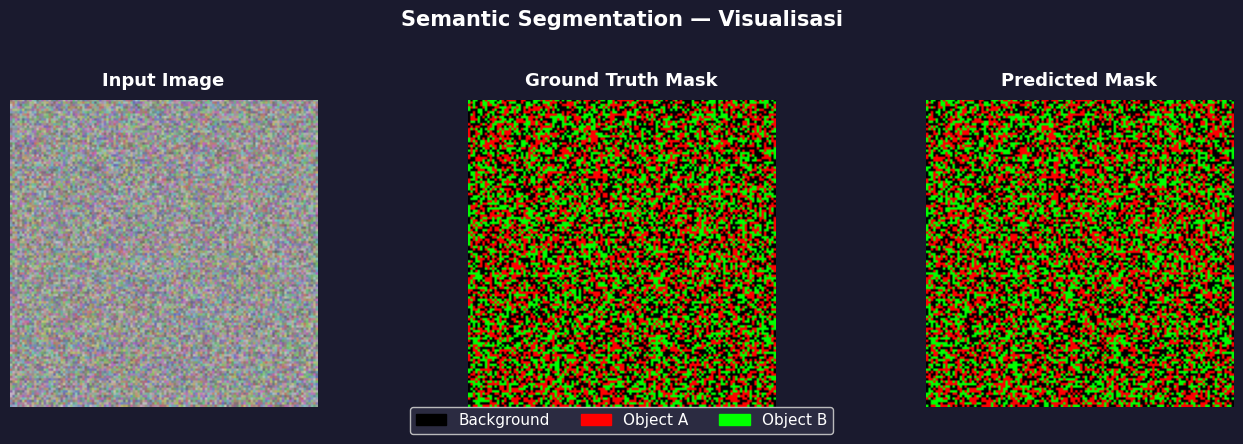

In [18]:
PALETTE = np.array([
    [0,   0,   0  ],
    [255, 0,   0  ],
    [0,   255, 0  ],
], dtype=np.uint8)

def mask_to_rgb(mask, palette):
    return palette[mask]


np.random.seed(7)
fake_image = np.random.randint(100, 200, (128, 128, 3), dtype=np.uint8)
true_rgb   = mask_to_rgb(true_mask, PALETTE)
pred_rgb   = mask_to_rgb(pred_mask, PALETTE)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#1a1a2e')

titles = ['Input Image', 'Ground Truth Mask', 'Predicted Mask']
images = [fake_image, true_rgb, pred_rgb]

for ax, title, img in zip(axes, titles, images):
    ax.imshow(img)
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

patches = [
    mpatches.Patch(color=PALETTE[i] / 255, label=CLASS_NAMES[i])
    for i in range(NUM_CLASSES)
]
fig.legend(handles=patches, loc='lower center', ncol=NUM_CLASSES,
           facecolor='#2d2d44', labelcolor='white', fontsize=11,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Semantic Segmentation — Visualisasi', color='white',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

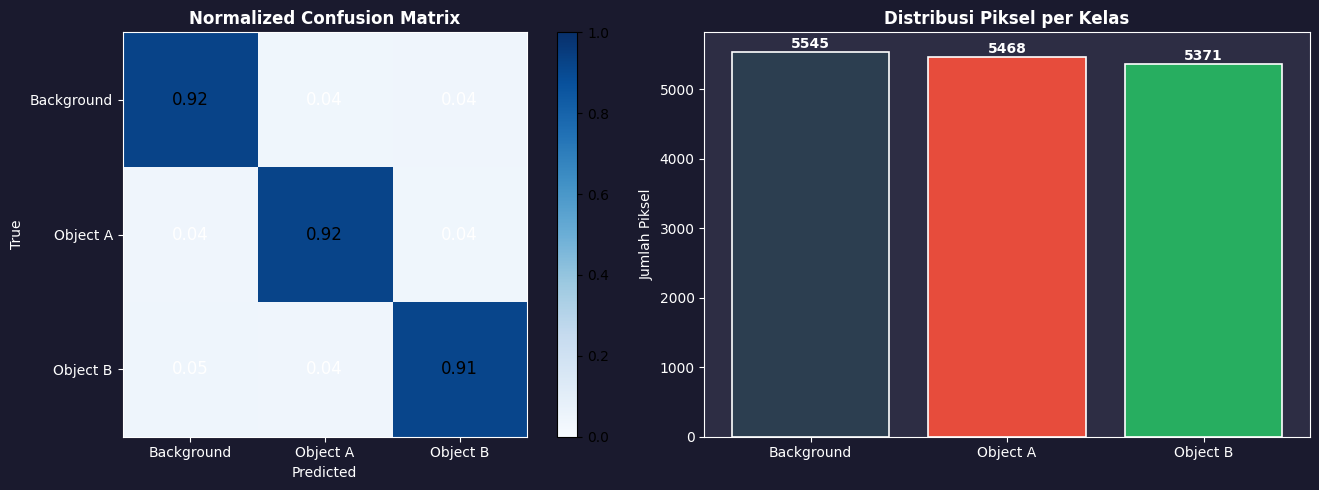

In [19]:
cm      = confusion_matrix(true_mask.flatten(), pred_mask.flatten())
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')

im = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_yticks(range(NUM_CLASSES))
axes[0].set_xticklabels(CLASS_NAMES, color='white')
axes[0].set_yticklabels(CLASS_NAMES, color='white')
axes[0].set_xlabel('Predicted', color='white')
axes[0].set_ylabel('True', color='white')
axes[0].set_title('Normalized Confusion Matrix', color='white', fontweight='bold')
axes[0].tick_params(colors='white')
for spine in axes[0].spines.values():
    spine.set_edgecolor('white')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = round(cm_norm[i, j], 2)
        col = 'white' if cm_norm[i, j] < 0.6 else 'black'
        axes[0].text(j, i, str(val), ha='center', va='center', color=col, fontsize=12)
plt.colorbar(im, ax=axes[0])

counts = [int(np.sum(true_mask == k)) for k in range(NUM_CLASSES)]
colors = ['#2c3e50', '#e74c3c', '#27ae60']
bars   = axes[1].bar(CLASS_NAMES, counts, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_facecolor('#2d2d44')
axes[1].set_title('Distribusi Piksel per Kelas', color='white', fontweight='bold')
axes[1].set_ylabel('Jumlah Piksel', color='white')
axes[1].tick_params(colors='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('white')
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50,
                 str(count), ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
from torch.utils.data import Dataset, DataLoader


class SyntheticSegDataset(Dataset):
    def __init__(self, num_samples=100, img_size=128, num_classes=3):
        self.num_samples = num_samples
        self.img_size    = img_size
        self.num_classes = num_classes

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        np.random.seed(idx)
        image = torch.randn(3, self.img_size, self.img_size)
        mask  = torch.randint(0, self.num_classes, (self.img_size, self.img_size))
        return image, mask


train_ds = SyntheticSegDataset(num_samples=80)
val_ds   = SyntheticSegDataset(num_samples=20)
train_dl = DataLoader(train_ds, batch_size=4, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=4)

model     = UNet(in_channels=3, num_classes=3, features=[16, 32, 64]).to(DEVICE)
criterion = CombinedLoss(alpha=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        loss  = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss, all_iou = 0, []
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        loss  = criterion(preds, masks)
        total_loss += loss.item()
        pred_labels = preds.argmax(dim=1).cpu().numpy()
        true_labels = masks.cpu().numpy()
        m = compute_metrics(pred_labels, true_labels, num_classes)
        all_iou.append(m['mIoU'])
    return total_loss / len(loader), np.mean(all_iou)


EPOCHS  = 5
history = {'train_loss': [], 'val_loss': [], 'val_miou': []}

header = "Epoch    Train Loss   Val Loss     mIoU"
print(header)
print('=' * 42)

for epoch in range(1, EPOCHS + 1):
    tr_loss          = train_one_epoch(model, train_dl, optimizer, criterion, DEVICE)
    vl_loss, vl_miou = validate(model, val_dl, criterion, DEVICE, num_classes=3)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_miou'].append(vl_miou)

    row = str(epoch).rjust(5) + "  " + str(round(tr_loss, 4)).rjust(10) + "  " + \
          str(round(vl_loss, 4)).rjust(8) + "  " + str(round(vl_miou, 4)).rjust(6)
    print(row)

Epoch    Train Loss   Val Loss     mIoU
    1       0.895    0.8852  0.1518
    2      0.8838    0.8832  0.1927
    3      0.8829    0.8829  0.1878
    4      0.8828    0.8828  0.1984
    5      0.8827    0.8828  0.1985


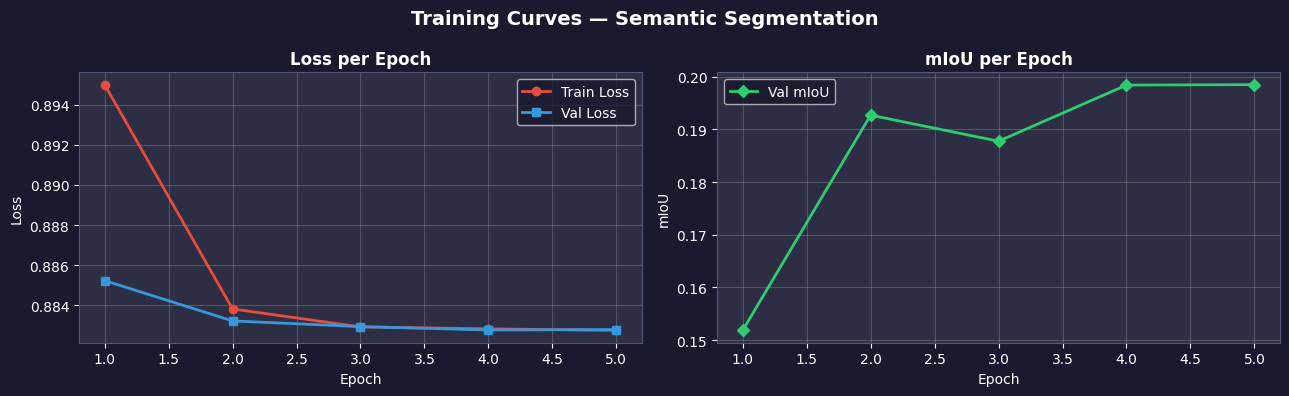

In [21]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#1a1a2e')

for ax in axes:
    ax.set_facecolor('#2d2d44')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555577')

axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#e74c3c', linewidth=2, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   's-', color='#3498db', linewidth=2, label='Val Loss')
axes[0].set_title('Loss per Epoch', color='white', fontweight='bold')
axes[0].set_xlabel('Epoch', color='white')
axes[0].set_ylabel('Loss', color='white')
axes[0].legend(facecolor='#1a1a2e', labelcolor='white')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['val_miou'], 'D-', color='#2ecc71', linewidth=2, label='Val mIoU')
axes[1].set_title('mIoU per Epoch', color='white', fontweight='bold')
axes[1].set_xlabel('Epoch', color='white')
axes[1].set_ylabel('mIoU', color='white')
axes[1].legend(facecolor='#1a1a2e', labelcolor='white')
axes[1].grid(alpha=0.3)

plt.suptitle('Training Curves — Semantic Segmentation', color='white',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Berhasil: https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg


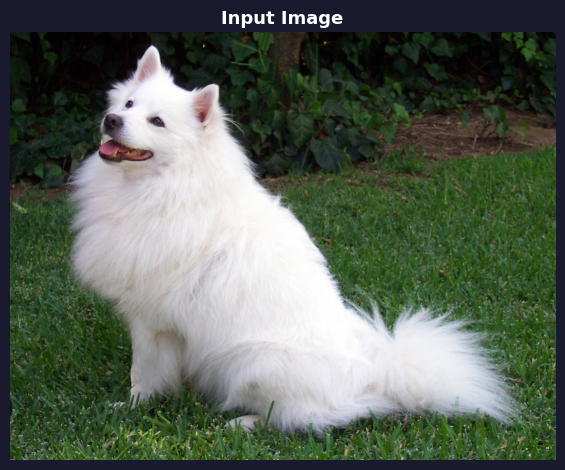

In [24]:
import requests
import torchvision.models.segmentation as seg_models
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import io

headers = {'User-Agent': 'Mozilla/5.0'}

urls = [
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    "https://raw.githubusercontent.com/ultralytics/assets/main/im/image8.jpg",
]

image = None
for url in urls:
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        resp.raise_for_status()
        image = Image.open(io.BytesIO(resp.content)).convert("RGB")
        print("Berhasil:", url)
        break
    except Exception as e:
        print("Gagal:", e)

if image is None:
    print("Membuat gambar sintetis sebagai fallback...")
    np.random.seed(0)
    arr = np.zeros((520, 520, 3), dtype=np.uint8)
    arr[:260, :, :]  = [70, 130, 180]
    arr[260:, :, :]  = [34, 139, 34]
    arr[150:370, 180:340, :] = [210, 180, 140]
    image = Image.fromarray(arr)

preprocess = transforms.Compose([
    transforms.Resize((520, 520)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(image).unsqueeze(0)

plt.figure(facecolor='#1a1a2e')
plt.imshow(image)
plt.axis('off')
plt.title('Input Image', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
model_seg = seg_models.deeplabv3_resnet50(weights='DEFAULT')
model_seg.eval()

with torch.no_grad():
    output = model_seg(input_tensor)['out']

pred_mask = output.argmax(dim=1).squeeze(0).numpy()

print("Output logits shape :", tuple(output.shape))
print("Predicted mask shape:", pred_mask.shape)
print("Kelas terdeteksi    :", np.unique(pred_mask))

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\Devan/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth
100%|███████████████████████████████████████████████████████████████████████████████| 161M/161M [00:59<00:00, 2.81MB/s]


Output logits shape : (1, 21, 520, 520)
Predicted mask shape: (520, 520)
Kelas terdeteksi    : [ 0 12]


In [26]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog',
    'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa',
    'train', 'tvmonitor'
]

VOC_PALETTE = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],[128,0,128],
    [0,128,128],[128,128,128],[64,0,0],[192,0,0],[64,128,0],[192,128,0],
    [64,0,128],[192,0,128],[64,128,128],[192,128,128],[0,64,0],[128,64,0],
    [0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

def colorize_mask(mask, palette):
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_idx, color in enumerate(palette):
        color_mask[mask == cls_idx] = color
    return color_mask

color_mask = colorize_mask(pred_mask, VOC_PALETTE)

detected_ids   = np.unique(pred_mask)
detected_names = [VOC_CLASSES[i] for i in detected_ids if i < len(VOC_CLASSES)]
print("Objek terdeteksi:", detected_names)

Objek terdeteksi: ['background', 'dog']


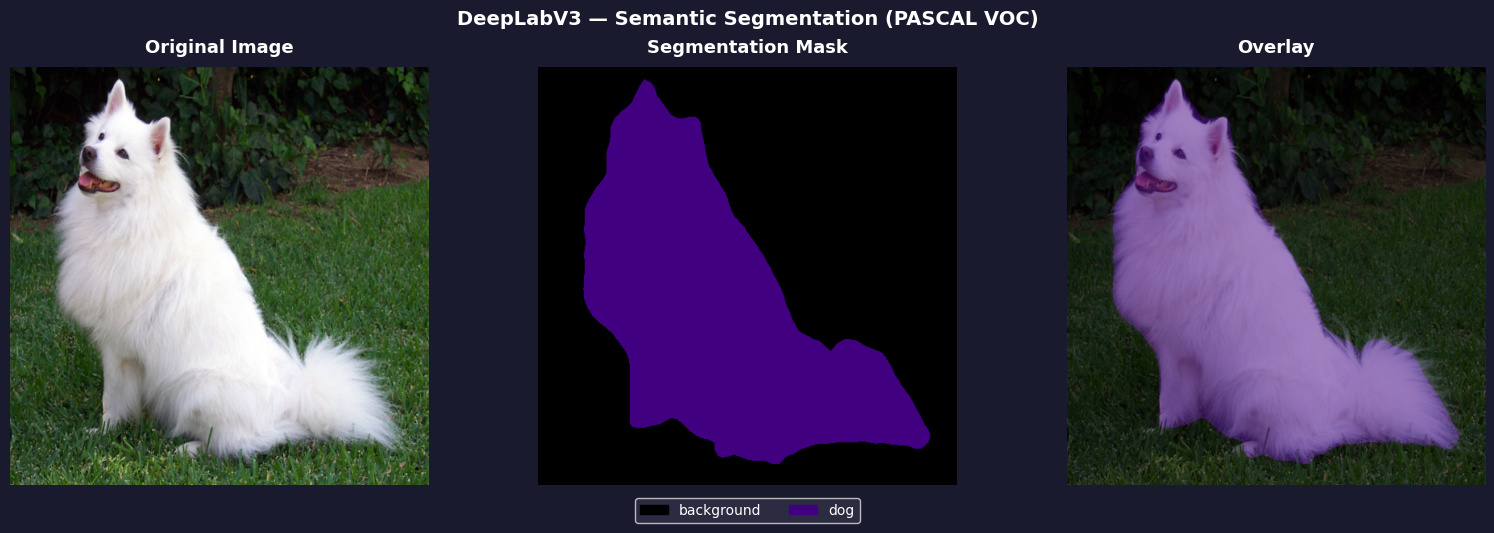

In [27]:
image_resized = image.resize((520, 520))
image_np      = np.array(image_resized)

overlay = (0.5 * image_np + 0.5 * color_mask).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#1a1a2e')

data   = [image_np, color_mask, overlay]
titles = ['Original Image', 'Segmentation Mask', 'Overlay']

for ax, img, title in zip(axes, data, titles):
    ax.imshow(img)
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555577')

import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color=VOC_PALETTE[i] / 255.0, label=VOC_CLASSES[i])
    for i in detected_ids if i < len(VOC_CLASSES)
]
fig.legend(handles=patches, loc='lower center', ncol=len(patches),
           facecolor='#2d2d44', labelcolor='white', fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

plt.suptitle('DeepLabV3 — Semantic Segmentation (PASCAL VOC)',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

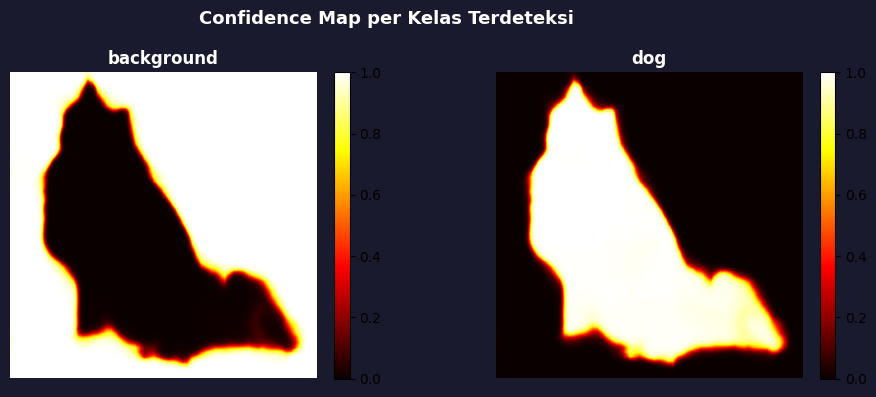

In [28]:
probs = torch.softmax(output, dim=1).squeeze(0).numpy()

n_cols = len(detected_ids)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))
fig.patch.set_facecolor('#1a1a2e')

if n_cols == 1:
    axes = [axes]

for ax, cls_id in zip(axes, detected_ids):
    name = VOC_CLASSES[cls_id] if cls_id < len(VOC_CLASSES) else str(cls_id)
    im   = ax.imshow(probs[cls_id], cmap='hot', vmin=0, vmax=1)
    ax.set_title(name, color='white', fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Confidence Map per Kelas Terdeteksi',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()